# NP.ENS KBDD - simulation (P = 10, exhaustive labelling)

In [1]:
import os, math, time, random, itertools, warnings
os.environ['PYTHONWARNINGS'] = 'ignore'  
warnings.filterwarnings('ignore')       
import numpy as np
import networkx as nx
import scipy.stats as stats
import powerlaw
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

In [2]:
# ---- configuration ----
BASE = 'data/simulation'   # 100 true networks + expression matrices, shipped with this folder
M = 100               # number of degree sequences
TOP_FRAC = 0.01       # top 1% of potential networks by Deviation
N_FOLDS = 100         # leave-one-out replications
N_JOBS = 8            # parallel workers

## Core functions (Erdos-Gallai enumeration + exhaustive labelling)

In [3]:
_PERMS_CACHE = {}

def EGtest(DS_input):
    if np.sum(DS_input) % 2 == 1 or np.sum(DS_input) > len(DS_input) * (len(DS_input) - 1):
        return 'failure'
    if np.sum(DS_input) != 0 and 0 in DS_input:
        DS_input = np.delete(DS_input, np.where(DS_input == 0))
    DS_input = np.sort(DS_input)[::-1]
    for index in range(len(DS_input)):
        k = index + 1
        tmp_DS_input = np.array([
            k if DS_input[x] > k and x >= k else DS_input[x] for x in range(len(DS_input))
        ])
        if sum(tmp_DS_input[0:k]) > k * (k - 1) + np.sum(tmp_DS_input[k:]):
            return 'failure'
    return 'success'


def rightmost_adj(DS_input):
    non_zero_degree_node_index = np.array([i for i, x in enumerate(DS_input) if x > 0])
    if 0 in DS_input:
        DS_input = np.delete(DS_input, np.where(DS_input == 0))
    order_index = np.argsort(-DS_input)
    DS_input = np.sort(DS_input)[::-1]
    rightmost_adj_set = np.array([], dtype=int)
    for non_leading_node in range(1, len(DS_input))[::-1]:
        tmp_DS = np.copy(DS_input)
        tmp_DS[0] -= 1
        tmp_DS[non_leading_node] -= 1
        if tmp_DS[0] != 0:
            DS_for_test = np.array([tmp_DS[i] - 1 if i <= tmp_DS[0] else tmp_DS[i] for i in range(1, len(tmp_DS))])
        else:
            DS_for_test = np.copy(tmp_DS)
        if EGtest(DS_for_test) == 'success':
            rightmost_adj_set = np.append(rightmost_adj_set, non_leading_node)
            if tmp_DS[0] == 0:
                break
            DS_input = np.copy(tmp_DS)
    rightmost_adj_set = np.array(non_zero_degree_node_index[order_index[rightmost_adj_set]])
    return rightmost_adj_set


def left_adj(current_adj_mat, DS_input_original, DS_input_current, rightmost_adj, leading_node_index):
    leading_node_degree = DS_input_current[leading_node_index]
    tmp_DS = np.copy(DS_input_current)
    tmp_DS[leading_node_index] = 0
    order_index = np.argsort(-tmp_DS)
    tmp_DS = np.sort(tmp_DS)[::-1]
    non_zero_DS = np.delete(tmp_DS, np.where(tmp_DS == 0))
    number_of_min = len(np.where(non_zero_DS == min(non_zero_DS))[0])
    non_min_node_index = np.where(non_zero_DS != min(non_zero_DS))[0]
    number_of_non_min = len(non_min_node_index)
    tmp_left_adj_set = [[0] * leading_node_degree]
    i_start = max(leading_node_degree - number_of_min, 0)
    i_end = max(min(number_of_non_min, leading_node_degree), 0) + 1
    duplicate_marker = [mat.copy() for mat in current_adj_mat]
    [duplicate_marker[i].append(DS_input_original[i]) for i in range(len(DS_input_original))]
    duplicated_index = [0] * len(duplicate_marker)
    for i in range(len(duplicate_marker)):
        for j in range(len(duplicate_marker)):
            if duplicate_marker[j] == duplicate_marker[i]:
                duplicated_index[i] = j
    duplicated_index = [duplicated_index[order_index[i]] for i in range(len(order_index))]
    for i in range(i_start, i_end):
        if i == 1 and number_of_non_min == 1:
            first_part = [list(non_min_node_index)]
        elif i != 0:
            first_part = [list(l) for l in itertools.combinations(non_min_node_index, i)]
            duplicated_mat = [0] * len(first_part)
            for j in range(len(first_part)):
                duplicated_mat[j] = [duplicated_index[first_part[j][k]] for k in range(len(first_part[j]))]
            unique_index = []
            unique_value = []
            for j in range(len(duplicated_mat))[::-1]:
                x = duplicated_mat[j]
                if x not in unique_value:
                    unique_value.append(x)
                    unique_index.append(j)
            first_part = [first_part[m] for m in range(len(first_part)) if m in unique_index]
        if i != leading_node_degree:
            min_degree_node = np.where(non_zero_DS == min(non_zero_DS))[0]
            if len(min_degree_node) == 1:
                second_part = [list(min_degree_node)]
            else:
                second_part = [list(l) for l in itertools.combinations(min_degree_node, leading_node_degree - i)]
            duplicated_mat = [0] * len(second_part)
            for j in range(len(second_part)):
                duplicated_mat[j] = [duplicated_index[second_part[j][k]] for k in range(len(second_part[j]))]
            unique_index = []
            unique_value = []
            for j in range(len(duplicated_mat))[::-1]:
                x = duplicated_mat[j]
                if x not in unique_value:
                    unique_value.append(x)
                    unique_index.append(j)
            second_part = [second_part[m] for m in range(len(second_part)) if m in unique_index]
        if i == 0:
            combine_two_part = second_part
        elif i == leading_node_degree:
            combine_two_part = first_part
        else:
            combine_two_part = [x + y for x in first_part for y in second_part]
        tmp_left_adj_set = tmp_left_adj_set + combine_two_part
    tmp_left_adj_set.remove(tmp_left_adj_set[0])
    mapping_index = [np.where(tmp_DS == tmp_DS[k])[0][0] for k in range(len(tmp_DS))]
    colex_order_rightmost = [np.where(order_index == rightmost_adj[i])[0][0] for i in range(len(rightmost_adj))]
    colex_score_rightmost = np.sum([2 ** (mapping_index[colex_order_rightmost[i]]) for i in range(len(colex_order_rightmost))])
    colex_score_left = []
    for i in range(len(tmp_left_adj_set)):
        colex_score_i = np.sum([2 ** (mapping_index[tmp_left_adj_set[i][j]]) for j in range(len(colex_order_rightmost))])
        colex_score_left.append(colex_score_i)
    check_to_the_left = np.array(colex_score_left <= colex_score_rightmost, dtype=bool)
    tmp_left_adj_set = np.asarray(tmp_left_adj_set)
    left_adj_set = tmp_left_adj_set[check_to_the_left]
    left_adj_set = [list(order_index[k]) for k in left_adj_set]
    return left_adj_set


def connect_adj_set(leading_node_index, current_adj_mat, adj_set):
    output_mat = []
    for ii in range(len(adj_set)):
        tmp_mat = [row.copy() for row in current_adj_mat]
        for jj in range(len(adj_set[0])):
            tmp_mat[leading_node_index][adj_set[ii][jj]] = tmp_mat[adj_set[ii][jj]][leading_node_index] = 1
        output_mat.append([row.copy() for row in tmp_mat])
    return output_mat


def net_gen(original_DS):
    sum_DS = np.sum(original_DS)
    rows, cols = len(original_DS), len(original_DS)
    incomplete_adj_mat = [[[0] * cols for _ in range(rows)]]
    complete_adj_mat = []
    max_complete_mat_count = 1000
    while incomplete_adj_mat and len(complete_adj_mat) < max_complete_mat_count:
        last_matrix = incomplete_adj_mat.pop()
        current_DS = original_DS - np.array([sum(row) for row in last_matrix])
        if np.sum(current_DS != 0) > 1:
            leading_node = np.argmax(current_DS)
            rightmost_adj_set = rightmost_adj(current_DS)
            left_adj_set = left_adj(
                current_adj_mat=last_matrix,
                DS_input_original=original_DS,
                DS_input_current=current_DS,
                rightmost_adj=rightmost_adj_set,
                leading_node_index=leading_node,
            )
            new_matrices = connect_adj_set(
                leading_node_index=leading_node,
                current_adj_mat=last_matrix,
                adj_set=left_adj_set,
            )
            for matrix in new_matrices:
                if sum([sum(row) for row in matrix]) == sum_DS:
                    complete_adj_mat.append(matrix)
                else:
                    incomplete_adj_mat.append(matrix)
    return complete_adj_mat


def truncated_power_law(alpha, maximum_value):
    x = np.arange(1, maximum_value + 1, dtype='float')
    pmf = 1 / x ** alpha
    pmf /= pmf.sum()
    return stats.rv_discrete(values=(range(1, maximum_value + 1), pmf))


def calculate_network_properties(networks):
    ave_path_len = []
    max_degree_centrality = []
    transitivity = []
    for net in networks:
        G = nx.from_numpy_array(np.array(net))
        dis_mat = nx.floyd_warshall_numpy(G)
        dis_mat_without_inf = np.where(np.isinf(dis_mat), len(dis_mat), dis_mat)
        ave_path_length = dis_mat_without_inf.sum() / len(dis_mat) / len(dis_mat)
        ave_path_len.append(ave_path_length)
        max_degree_centrality.append(max(nx.degree_centrality(G).values()))
        transitivity.append(nx.transitivity(G))
    return ave_path_len, max_degree_centrality, transitivity


def standardize_deviation(actual, mean):
    deviation = (actual - mean) / np.std(actual)
    deviation[np.isnan(deviation)] = 0
    return deviation


def pcor_abs(X):
    """|partial correlation| via the precision matrix (== |pingouin.pcorr|)."""
    X = np.asarray(X, dtype=float)
    cov = np.cov(X, rowvar=False)
    P = np.linalg.inv(cov)
    d = np.sqrt(np.diag(P))
    pc = -P / np.outer(d, d)
    np.fill_diagonal(pc, 1.0)
    return np.abs(pc)


def estimate_alpha(networks):
    """Mean and sd of the power-law exponent over the given networks (uses degree seq)."""
    alpha = []
    for mat in networks:
        degree_seq = [sum(row) for row in mat]
        degree_seq_non_zero = np.array([i for i in degree_seq if i != 0])
        fit = powerlaw.Fit(degree_seq_non_zero, xmin=1, discrete=True)
        alpha.append(fit.power_law.alpha)
    return float(np.mean(alpha)), float(np.std(alpha, ddof=1))


def _net_score(C, structure, perm):
    perm = list(perm)
    M = C[perm, :][:, perm]
    return float(np.sum(M * structure))


def _all_perms(P):
    if P not in _PERMS_CACHE:
        # Stream directly into an int8 array (P<=12) — avoids building a 3.6M-tuple Python list.
        n = math.factorial(P)
        flat = np.fromiter(itertools.chain.from_iterable(itertools.permutations(range(P))),
                           dtype=np.int8, count=n * P)
        _PERMS_CACHE[P] = flat.reshape(n, P)
    return _PERMS_CACHE[P]


def label_exhaustive(C, structure, P):
    """
    Vectorised global-optimum labeling. Identical result to label_exhaustive_slow (same
    itertools.permutations(range(P)) enumeration order -> same argmax tie-break), ~100x faster.
    score(perm) = sum_{i,j} C[perm[i],perm[j]] * structure[i,j]
                = 2 * sum_{(i,j) upper edges} C[perm[i],perm[j]]   (C, structure symmetric)
    """
    perms = _all_perms(P)                       # (P!, P)
    iu = np.triu_indices(P, 1)
    mask = np.asarray(structure)[iu] > 0
    ei, ej = iu[0][mask], iu[1][mask]
    if len(ei) == 0:
        return list(range(P)), 0.0
    C = np.asarray(C, dtype=float)
    scores = np.zeros(perms.shape[0], dtype=float)
    for a, b in zip(ei, ej):
        scores += C[perms[:, a], perms[:, b]]
    scores *= 2.0
    best = int(np.argmax(scores))
    return perms[best].tolist(), float(scores[best])


def gen_degree_sequences(kk, P, est_alpha, sd_alpha, M):
    """Replicate the original degree-sequence RNG exactly (deterministic per (kk,DS,ii))."""
    out = []
    for DS_count in range(M):
        ii = 0
        EG_result = "failure"
        sample_DS = None
        while EG_result == "failure":
            ii += 1
            np.random.seed((20220113 + kk + DS_count) * ii)
            input_alpha = np.random.normal(loc=est_alpha, scale=sd_alpha, size=1)
            d = truncated_power_law(alpha=input_alpha, maximum_value=P - 1)
            np.random.seed((20220113 + kk + DS_count) * ii)
            sample_DS = d.rvs(size=P)
            sample_DS.sort()
            sample_DS = sample_DS[::-1]
            if (sum(sample_DS) / 2) / math.comb(P, 2) <= 0.3:
                EG_result = EGtest(sample_DS)
        out.append(np.array(sample_DS))
    return out

In [4]:
# ---- construct the ensemble network for one leave-one-out fold (per-stage timing) ----

def build_one_network(kk, sample_network, ref_sparsity, data_dir, M=100, top_frac=0.01, n_jobs=1):
    P = len(sample_network[kk]); target = np.array(sample_network[kk]); par = n_jobs and n_jobs != 1
    tt = {}
    def _t(): return time.perf_counter()
    ref_nets = [sample_network[i] for i in range(len(sample_network)) if i != kk]
    s = _t(); est_alpha, sd_alpha = estimate_alpha(ref_nets); tt['alpha'] = _t() - s
    s = _t(); DS_list = gen_degree_sequences(kk, P, est_alpha, sd_alpha, M); tt['degree_seq'] = _t() - s
    s = _t()
    nets = Parallel(n_jobs=n_jobs)(delayed(net_gen)(ds) for ds in DS_list) if par else [net_gen(ds) for ds in DS_list]
    potential_net = [n for sub in nets for n in sub]; tt['pns_gen'] = _t() - s
    s = _t()
    lib_apl, lib_mdc, lib_tr = calculate_network_properties(ref_nets)
    if par and len(potential_net) > n_jobs:
        chunks = np.array_split(np.arange(len(potential_net)), n_jobs)
        parts = Parallel(n_jobs=n_jobs)(delayed(calculate_network_properties)([potential_net[i] for i in idx]) for idx in chunks if len(idx))
        pot_apl = [v for p in parts for v in p[0]]; pot_mdc = [v for p in parts for v in p[1]]; pot_tr = [v for p in parts for v in p[2]]
    else:
        pot_apl, pot_mdc, pot_tr = calculate_network_properties(potential_net)
    dev = (abs(standardize_deviation(np.array(pot_apl), np.mean(lib_apl)))
           + abs(standardize_deviation(np.array(pot_mdc), np.mean(lib_mdc)))
           + abs(standardize_deviation(np.array(pot_tr), np.mean(lib_tr))))
    tt['properties'] = _t() - s
    s = _t(); X = np.loadtxt(os.path.join(data_dir, 'label_gene_exp%d.csv' % kk), delimiter=','); C = pcor_abs(X); tt['confidence'] = _t() - s
    s = _t()
    top_n = max(1, int(len(potential_net) * top_frac)); order = np.argsort(dev); selected, graphs = [], []
    for idx in order:
        if len(selected) >= top_n: break
        net = np.array(potential_net[idx]); g = nx.from_numpy_array(net)
        if any(nx.is_isomorphic(gp, g) for gp in reversed(graphs)): continue
        graphs.append(g); selected.append(net)
    tt['select'] = _t() - s
    s = _t()
    labeled = Parallel(n_jobs=n_jobs)(delayed(label_exhaustive)(C, st, P) for st in selected) if par else [label_exhaustive(C, st, P) for st in selected]
    tt['labeling'] = _t() - s
    s = _t()
    il = np.tril_indices(P, -1); at = target[il]; pos = np.where(at == 1)[0]; neg = np.where(at != 1)[0]
    relabeled = []
    for (perm, _), st in zip(labeled, selected):
        match = [perm.index(j) for j in range(P)]; relabeled.append(st[:, match][match, :])
    prop = np.sum(relabeled, axis=0) / len(relabeled); ths = np.arange(0, 1.05, 0.05)
    sp = [np.count_nonzero(prop > th) / (P * (P - 1)) for th in ths]
    tstar = round(float(ths[int(np.argmin([abs(x - ref_sparsity) for x in sp]))]), 2)
    ens = np.where(prop > tstar, 1, 0); ae = ens[il]
    TP = int(ae[pos].sum()); FP = int(ae[neg].sum()); FN = len(pos) - TP; TN = len(neg) - FP
    sens = TP / (TP + FN) if (TP + FN) else 0.0; spec = TN / (TN + FP) if (TN + FP) else 0.0; acc = (TP + TN) / (TP + TN + FN + FP)
    tt['ensemble'] = _t() - s
    return dict(kk=kk, sens=sens, spec=spec, acc=acc, tstar=tstar, ens=ens, target=target,
                n_potential=len(potential_net), n_selected=len(selected), timing=tt,
                apl=pot_apl, mdc=pot_mdc, tr=pot_tr, total=sum(tt.values()))

In [5]:
# ---- load the scenario (100 ground-truth networks + mean reference sparsity) ----

sample_network, ref_sparsity = [], []
for i in range(N_FOLDS):
    net = np.loadtxt(os.path.join(BASE, 'true_network%d.csv' % i), delimiter=',')
    sample_network.append(net); ref_sparsity.append(np.count_nonzero(net) / (net.shape[0] * (net.shape[0] - 1)))
ref_sparsity_mean = float(np.mean(ref_sparsity)); P = sample_network[0].shape[0]
print('scenario:', N_FOLDS, 'networks | P =', P, '| mean reference sparsity =', round(ref_sparsity_mean, 3))

scenario: 100 networks | P = 10 | mean reference sparsity = 0.2


In [6]:
# ---- STEP: one construction on a SINGLE CPU core (matches the reported per-network runtime) ----

t0 = time.time()
r0 = build_one_network(0, sample_network, ref_sparsity_mean, BASE, M=M, top_frac=TOP_FRAC, n_jobs=1)
print('single construction (P=%d, exhaustive P!, 1 core): %.2f s' % (P, time.time() - t0))
print('  per-stage (s):', {k: round(v, 3) for k, v in r0['timing'].items()})
print('  n_potential=%d n_selected=%d t*=%.2f | SEN=%.2f SPC=%.2f ACC=%.2f'
      % (r0['n_potential'], r0['n_selected'], r0['tstar'], r0['sens'], r0['spec'], r0['acc']))

single construction (P=10, exhaustive P!, 1 core): 10.41 s
  per-stage (s): {'alpha': 0.026, 'degree_seq': 0.111, 'pns_gen': 1.258, 'properties': 0.593, 'confidence': 0.004, 'select': 0.042, 'labeling': 8.37, 'ensemble': 0.001}
  n_potential=3468 n_selected=34 t*=0.40 | SEN=0.89 SPC=0.97 ACC=0.96


In [7]:
# ---- STEP: all 100 replications (parallel across folds) -> performance ----

t0 = time.time()
results = Parallel(n_jobs=N_JOBS)(delayed(build_one_network)(kk, sample_network, ref_sparsity_mean, BASE, M, TOP_FRAC, 1) for kk in range(N_FOLDS))
sen = np.array([r['sens'] for r in results]); spc = np.array([r['spec'] for r in results]); acc = np.array([r['acc'] for r in results])
print('all %d folds (parallel across folds, %d cores): %.1f s' % (N_FOLDS, N_JOBS, time.time() - t0))
print('  SEN %.3f(%.3f) | SPC %.3f(%.3f) | ACC %.3f(%.3f)' % (sen.mean(), sen.std(), spc.mean(), spc.std(), acc.mean(), acc.std()))

all 100 folds (parallel across folds, 8 cores): 141.3 s
  SEN 0.898(0.103) | SPC 0.976(0.024) | ACC 0.961(0.039)


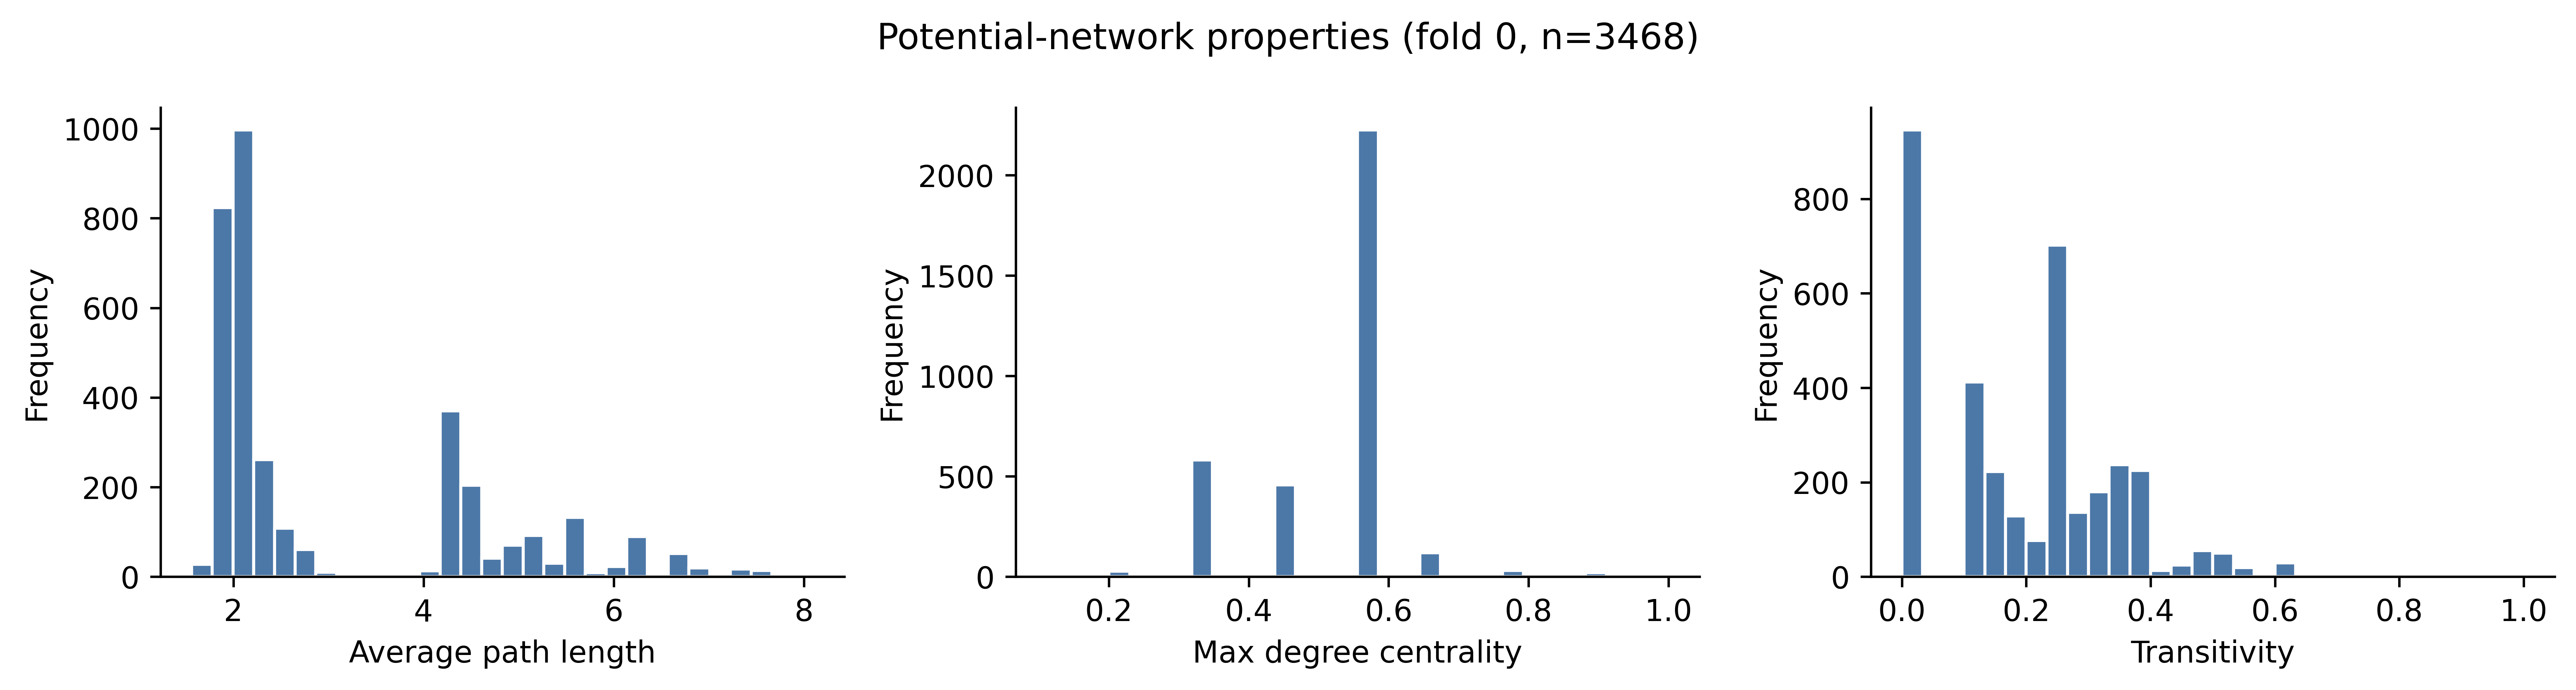

In [8]:
# ---- plot: potential-network property distributions (fold 0) ----

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), dpi=600)
for ax, vals, name in zip(axes, [r0['apl'], r0['mdc'], r0['tr']], ['Average path length', 'Max degree centrality', 'Transitivity']):
    ax.hist(vals, bins=30, color='#4C78A8', edgecolor='white'); ax.set_xlabel(name); ax.set_ylabel('Frequency')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.suptitle('Potential-network properties (fold 0, n=%d)' % r0['n_potential'])
fig.tight_layout(); plt.savefig('sim_P10_properties.png', dpi=150, bbox_inches='tight'); plt.show()

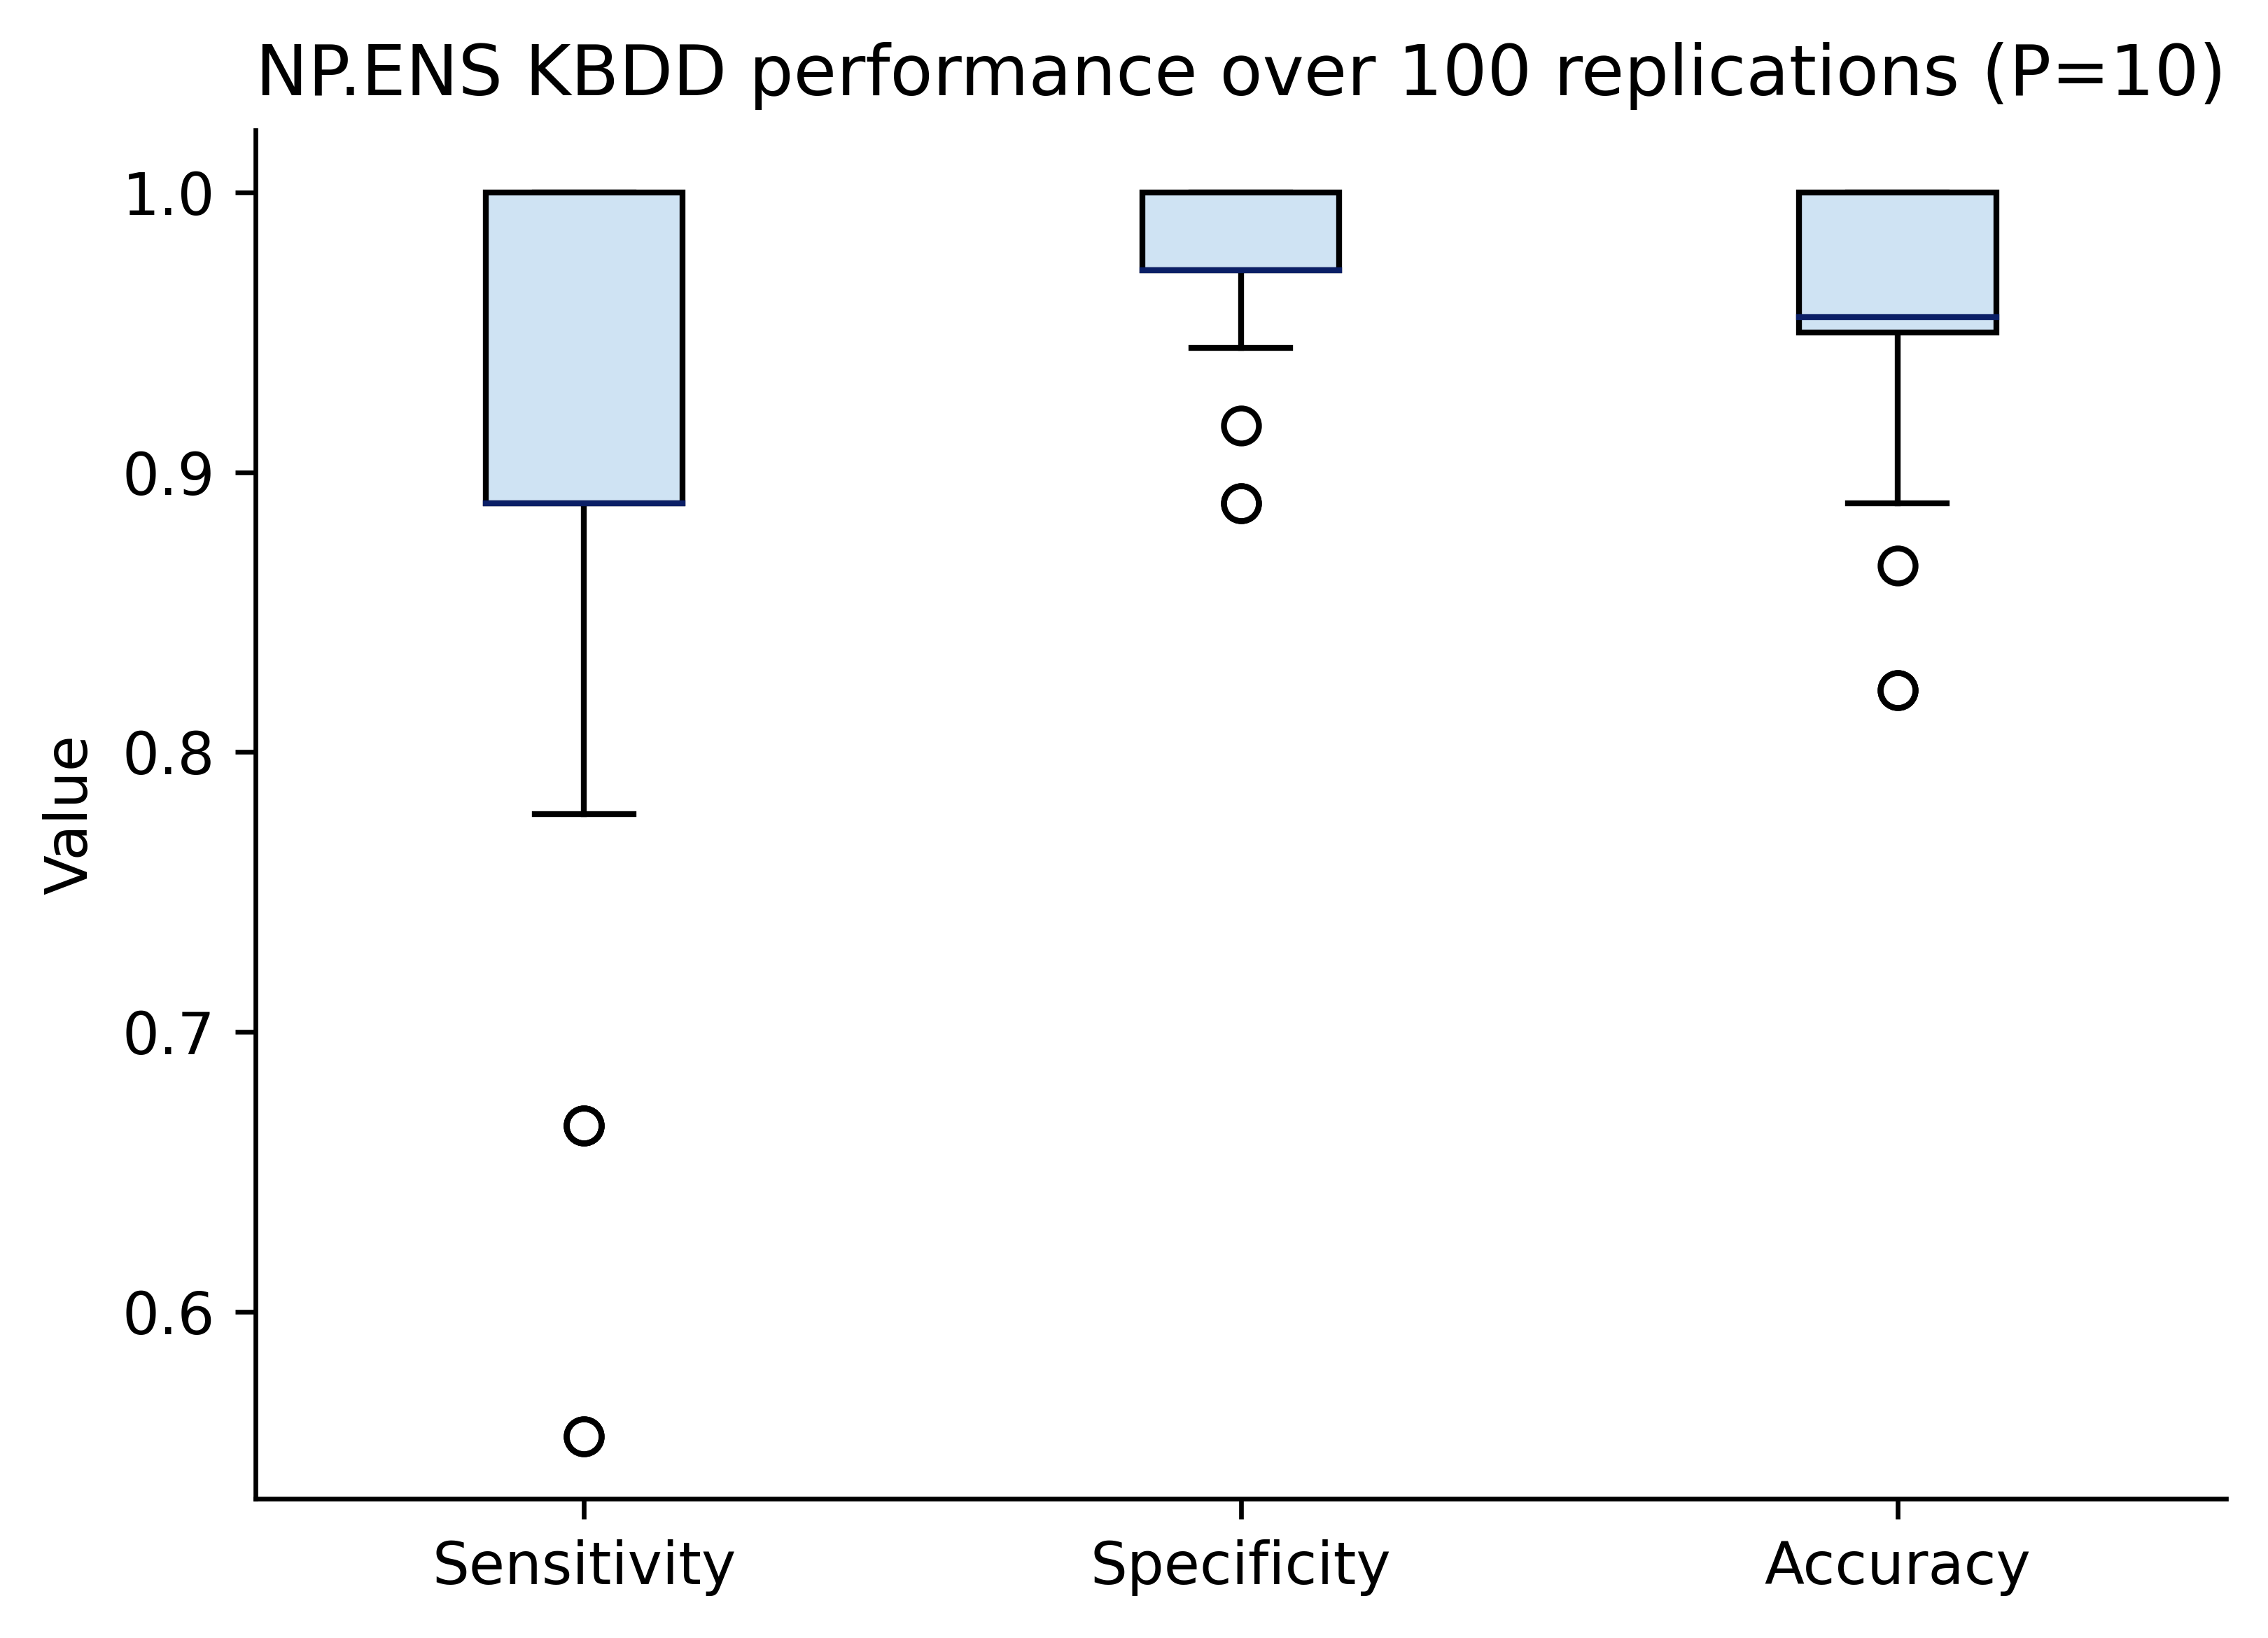

In [9]:
# ---- plot: SEN / SPC / ACC over the 100 replications ----

fig, ax = plt.subplots(figsize=(5.5, 4), dpi=600)
bp = ax.boxplot([sen, spc, acc], labels=['Sensitivity', 'Specificity', 'Accuracy'], patch_artist=True,
                boxprops=dict(facecolor='#cfe3f3'), medianprops=dict(color='#0B1F66'))
ax.set_ylabel('Value'); ax.set_title('NP.ENS KBDD performance over %d replications (P=%d)' % (N_FOLDS, P))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.tight_layout(); plt.savefig('sim_P10_performance.png', dpi=150, bbox_inches='tight'); plt.show()

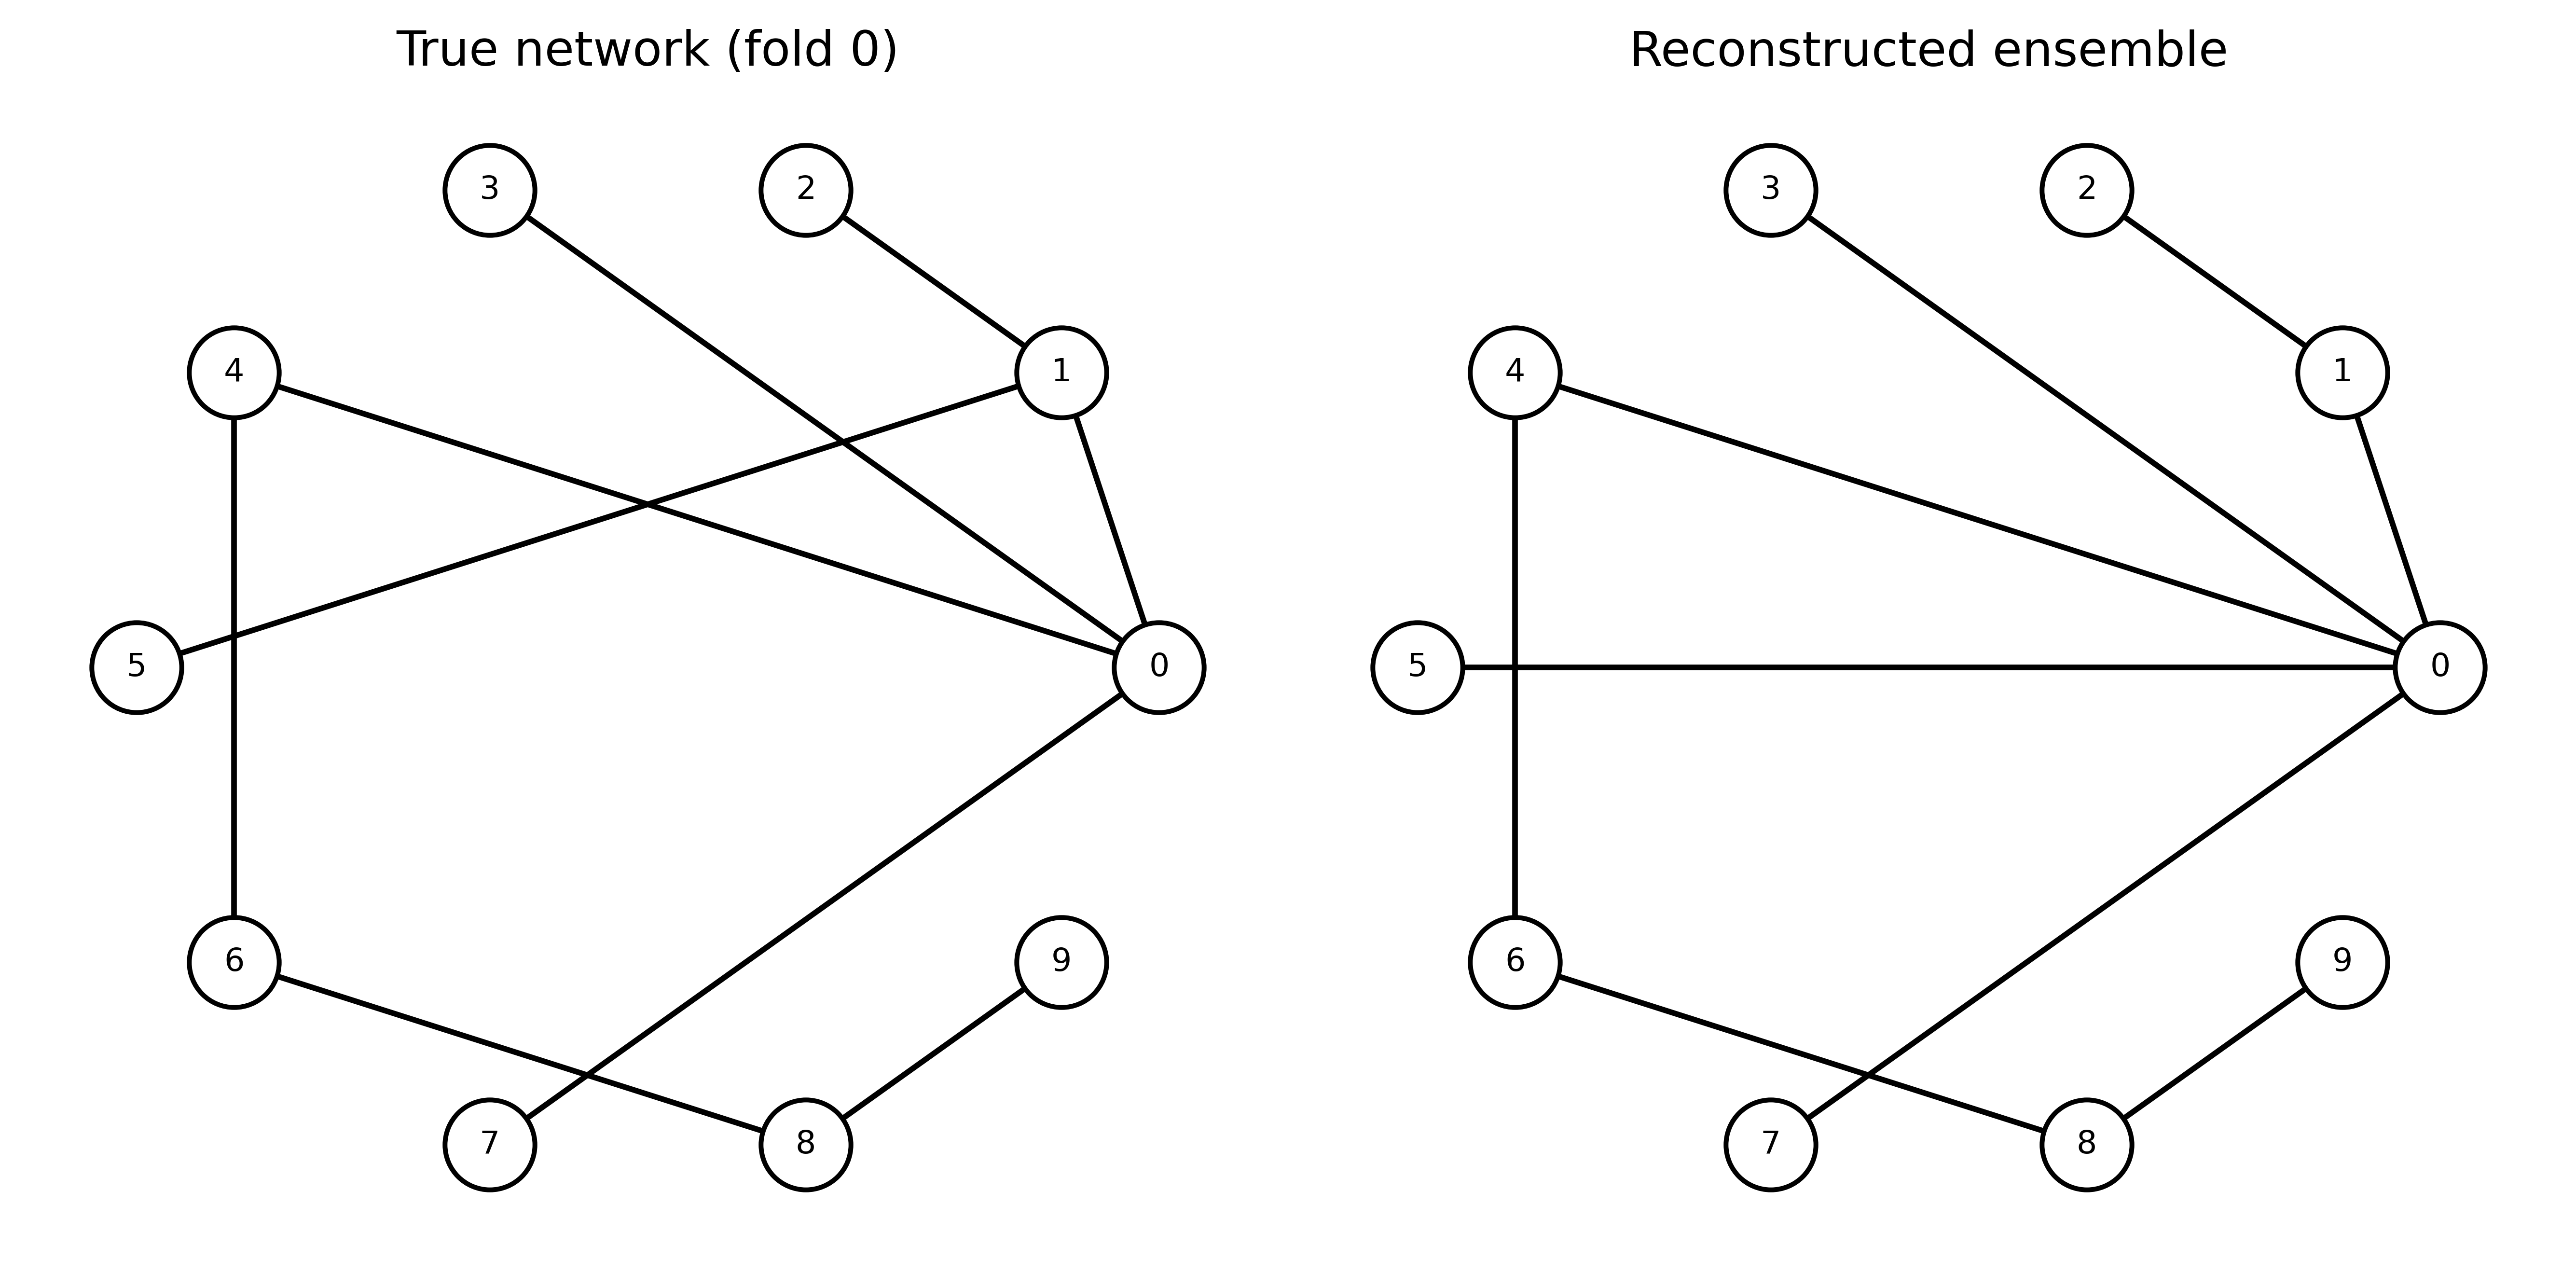

In [10]:
# ---- plot: true vs reconstructed ensemble network (fold 0) ----

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), dpi = 600)
for ax, A, title in zip(axes, [r0['target'], r0['ens']], ['True network (fold 0)', 'Reconstructed ensemble']):
    G = nx.from_numpy_array(np.array(A)); pos = nx.circular_layout(G)
    nx.draw_networkx_edges(G, pos, edge_color='black', width=1.4, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_size=500, node_color='white', edgecolors='black', linewidths=1.2, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax); ax.axis('off'); ax.set_title(title)
fig.tight_layout(); plt.savefig('sim_P10_networks.png', dpi=150, bbox_inches='tight'); plt.show()